# Radioactive heating rate: total, $\beta$-decay, and $\alpha$-decay

Same WinNet-snapshot pipeline as `Claude_Heating_nucharts_2.ipynb` ($\alpha$) and
`Claude_Heating_nucharts_3.ipynb` ($\beta^-$), but instead of building a nuclide-chart
heatmap per snapshot, each snapshot's per-nuclide heating rates are summed to give a
**heating-rate-vs-time curve** (total, $\beta$-only, $\alpha$-only), plus a tool to
identify the **leading nuclide contributors** (by % of the total heating rate) between
1 and 500 days.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO
import os
import glob
import re
import ipywidgets as widgets
from IPython.display import display
from scipy.constants import physical_constants, speed_of_light as c
import pynucastro as pyna
from tqdm.notebook import tqdm

%matplotlib widget

m_u = physical_constants['atomic mass constant energy equivalent in MeV'][0]

In [2]:
SNAP_DIR      = 'Runs/Hypatia_calculations/Example_NSM_dyn_ejecta_4_trajectories/traj0003.dat/snaps'
REACLIB_PATH  = 'Data/Original_files/Reaclib_18_9_20'

X_FLOOR       = 1e-30  # abundances below this are ignored in the heating sums

DAY           = 86400.0   # [s]
T_MIN_DAYS    = 1          # leading-contributor window: lower bound [days]
T_MAX_DAYS    = 500        # leading-contributor window: upper bound [days]
TOP_N         = 8          # number of leading nuclei tracked/displayed

In [3]:
def parse_snapshot(path):
    """Parse one WinNet snapshot file.

    Returns (time [s], T9 [GK], rho [g/cm^3], df)
    where df has columns [N, Z, A, Y, X].
    """
    with open(path) as fh:
        lines = fh.readlines()

    vals = lines[1].split()
    time = float(vals[0])
    T9   = float(vals[1])
    rho  = float(vals[2])
    data_str = ''.join(lines[3:])
    df = pd.read_csv(
        StringIO(data_str),
        sep=r'\s+', header=None,
        names=['N', 'Z', 'Y', 'X'],
        dtype={'N': int, 'Z': int, 'Y': float, 'X': float},
    )
    df['A'] = df['N'] + df['Z']
    return time, T9, rho, df

## Decay rates and channel-specific prefactors
Load ReacLib, keep the alpha- and beta$^-$-decay rates (as in nucharts_2/_3), and precompute the constant part of each nuclide's heating rate.

In [4]:
rates_Reaclib_winnet = pyna.rates.library.ReacLibLibrary(libfile=REACLIB_PATH)

# Remove duplicate links (keep the one with nonzero derivative)
for pair in rates_Reaclib_winnet.find_duplicate_links():
    if pair[0].eval_deriv(1e9) == 0:
        rates_Reaclib_winnet.remove_rate(pair[1])
    else:
        rates_Reaclib_winnet.remove_rate(pair[0])

filter_alpha = pyna.RateFilter(
    products=['he4'],
    exact=False,
    max_reactants=1,
    max_products=2,
    filter_function=lambda r: r.Q > 0 and r.reactants[0].Z == r.products[0].Z + r.products[1].Z
)
rates_alpha = rates_Reaclib_winnet.filter(filter_alpha)
alpha_rates_list = rates_alpha.get_rates()

filter_beta_minus = pyna.RateFilter(
    max_reactants=1,
    max_products=1,
    filter_function=lambda r: r.Q > 0 and r.reactants[0].Z == r.products[0].Z - 1
)
rates_beta = rates_Reaclib_winnet.filter(filter_beta_minus)
beta_rates_list = rates_beta.get_rates()

print(f"Found {len(alpha_rates_list)} alpha decay rates")
print(f"Found {len(beta_rates_list)} beta-minus decay rates")

Found 1439 alpha decay rates
Found 4861 beta-minus decay rates


In [5]:
def build_prefactors(rate_list):
    """Precompute constant part of heating rate per nucleus:
        prefactor [erg/s/g per unit X] = lambda * Q * c^2 / m
    (x1e4: m^2/s^3 -> cm^2/s^3 = erg/s/g). Only X_i changes snapshot to snapshot,
    so this is computed once per decay channel.

    Returns ({(N, Z): prefactor}, {(N, Z): Nucleus}).
    """
    prefactors = {}
    nucleus_by_key = {}
    for rate in rate_list:
        nuclei = rate.reactants[0]
        Z_i, N_i = nuclei.Z, nuclei.N
        if not isinstance(nuclei.dm, float):
            continue
        m_i = nuclei.dm + (Z_i + N_i) * m_u
        if m_i <= 0:
            continue
        decay_rate_i = rate.eval(1e9)   # [s^-1] (T-independent for decay)
        Q_i = rate.Q                    # [MeV]
        prefactor = decay_rate_i * Q_i * c**2 / m_i * 1e4
        prefactors[(N_i, Z_i)] = prefactor
        nucleus_by_key[(N_i, Z_i)] = nuclei
    return prefactors, nucleus_by_key

alpha_prefactors, alpha_nucleus_by_key = build_prefactors(alpha_rates_list)
beta_prefactors, beta_nucleus_by_key = build_prefactors(beta_rates_list)

print(f"Precomputed prefactors for {len(alpha_prefactors)} alpha-emitting nuclei")
print(f"Precomputed prefactors for {len(beta_prefactors)} beta-emitting nuclei")

Precomputed prefactors for 1305 alpha-emitting nuclei
Precomputed prefactors for 1329 beta-emitting nuclei


In [6]:
snap_files = sorted(
    glob.glob(os.path.join(SNAP_DIR, 'snapsh_*.dat')),
    key=lambda p: int(re.search(r'snapsh_(\d+)\.dat', os.path.basename(p)).group(1))
)
print(f"Found {len(snap_files)} snapshots")

Found 598 snapshots


## Heating-rate time series
For every snapshot, look up each alpha-/beta-emitter's abundance and multiply by its prefactor to get its instantaneous heating rate. Summing over nuclei gives the total $\alpha$- and $\beta$-channel heating rate at that snapshot's time. Per-nuclide values are kept too (`eps_alpha_nuclei`, `eps_beta_nuclei`) for the leading-contributor analysis below.

In [7]:
alpha_keys = sorted(alpha_prefactors)
beta_keys  = sorted(beta_prefactors)
alpha_pref_arr = np.array([alpha_prefactors[k] for k in alpha_keys])
beta_pref_arr  = np.array([beta_prefactors[k] for k in beta_keys])
alpha_mi = pd.MultiIndex.from_tuples(alpha_keys, names=['N', 'Z'])
beta_mi  = pd.MultiIndex.from_tuples(beta_keys, names=['N', 'Z'])

n_snap  = len(snap_files)
time_s  = np.zeros(n_snap)
T9_arr  = np.zeros(n_snap)
rho_arr = np.zeros(n_snap)
eps_alpha_nuclei = np.zeros((len(alpha_keys), n_snap))  # [erg/s/g] per alpha-emitter, per snapshot
eps_beta_nuclei  = np.zeros((len(beta_keys), n_snap))   # [erg/s/g] per beta-emitter,  per snapshot

for idx, path in enumerate(tqdm(snap_files, desc='snapshots')):
    t_i, T9_i, rho_i, df_i = parse_snapshot(path)
    time_s[idx], T9_arr[idx], rho_arr[idx] = t_i, T9_i, rho_i

    mask = df_i['X'].values > X_FLOOR
    abundance = pd.Series(
        df_i['X'].values[mask],
        index=pd.MultiIndex.from_arrays([df_i['N'].values[mask], df_i['Z'].values[mask]]),
    )
    abundance = abundance[~abundance.index.duplicated()]

    eps_alpha_nuclei[:, idx] = alpha_pref_arr * abundance.reindex(alpha_mi, fill_value=0.0).values
    eps_beta_nuclei[:, idx]  = beta_pref_arr  * abundance.reindex(beta_mi,  fill_value=0.0).values

time_days = time_s / DAY
eps_alpha_total = eps_alpha_nuclei.sum(axis=0)
eps_beta_total  = eps_beta_nuclei.sum(axis=0)
eps_total       = eps_alpha_total + eps_beta_total

print(f"Processed {n_snap} snapshots spanning {time_days[0]:.3e} - {time_days[-1]:.1f} days")

snapshots:   0%|          | 0/598 [00:00<?, ?it/s]

Processed 598 snapshots spanning 0.000e+00 - 500.0 days


## Total heating rate vs. time

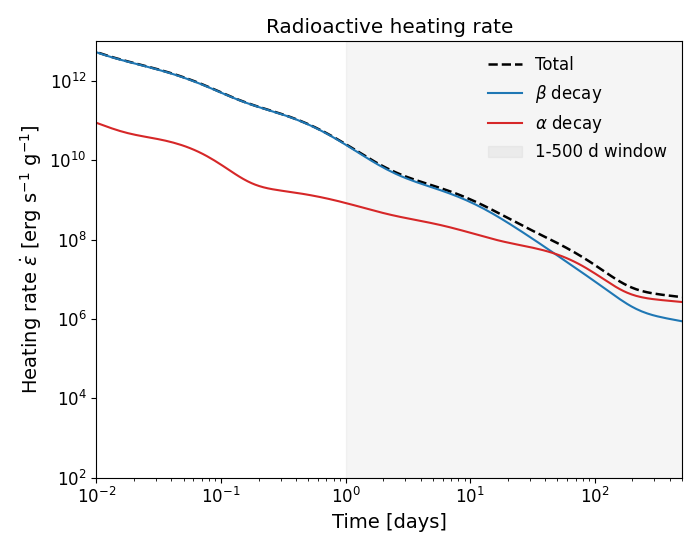

In [8]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig_rate, ax_rate = plt.subplots(figsize=(7, 5.5))
ax_rate.plot(time_days, eps_total,       color='black',    linestyle='--', label='Total', linewidth=1.8)
ax_rate.plot(time_days, eps_beta_total,  color='tab:blue', label=r'$\beta$ decay')
ax_rate.plot(time_days, eps_alpha_total, color='tab:red',  label=r'$\alpha$ decay')

ax_rate.axvspan(T_MIN_DAYS, T_MAX_DAYS, color='grey', alpha=0.08, zorder=0,
                 label=f'{T_MIN_DAYS}-{T_MAX_DAYS} d window')

ax_rate.set_xscale('log')
ax_rate.set_yscale('log')
ax_rate.set_xlabel('Time [days]')
ax_rate.set_xlim(0.01, 500)
ax_rate.set_ylim(1e2, 1e13)
ax_rate.set_ylabel(r'Heating rate $\dot\varepsilon$ [erg s$^{-1}$ g$^{-1}$]')
ax_rate.set_title('Radioactive heating rate')
ax_rate.legend(loc='upper right', frameon=False)
fig_rate.tight_layout()
fig_rate.savefig('heating_rate_vs_time.pdf', bbox_inches='tight', dpi=300)

## Leading nuclide contributors (1-500 days)
Stack the per-nuclide $\alpha$- and $\beta$-channel heating rates into one array (one row per nuclide/channel) and express each row as a **percentage of the total heating rate** at every snapshot. That percentage is what ranks the "leading contributors" below.

In [9]:
# A given nuclide can appear once per channel (its alpha- and beta-decay heating are
# tracked separately, since they populate different daughters and Q-values).
contrib_eps     = np.vstack([eps_alpha_nuclei, eps_beta_nuclei])          # [erg/s/g]
contrib_channel = ['alpha'] * len(alpha_keys) + ['beta'] * len(beta_keys)
contrib_key     = alpha_keys + beta_keys
nucleus_lookup  = {**alpha_nucleus_by_key, **beta_nucleus_by_key}
contrib_label   = [f"{nucleus_lookup[k]} ({ch})" for k, ch in zip(contrib_key, contrib_channel)]

def nearest_snap_index(day):
    """Index of the snapshot closest to `day` [days]."""
    target_s = day * DAY
    idx = np.searchsorted(time_s, target_s)
    idx = int(np.clip(idx, 0, n_snap - 1))
    if idx > 0 and abs(time_s[idx - 1] - target_s) < abs(time_s[idx] - target_s):
        idx -= 1
    return idx

def leading_contributors(day, top_n=TOP_N):
    """Top-`top_n` nuclide/channel contributors to the total heating rate at `day` [days],
    ranked by their percentage of the total heating rate. Returns (DataFrame, actual snapshot time [days]).
    """
    idx = nearest_snap_index(day)
    eps_i = contrib_eps[:, idx]
    total = eps_total[idx]
    pct = np.divide(eps_i, total, out=np.zeros_like(eps_i), where=total > 0) * 100
    order = np.argsort(-pct)[:top_n]
    table = pd.DataFrame({
        'nuclide':         [contrib_label[i] for i in order],
        'eps [erg/s/g]':   eps_i[order],
        '% of total':      pct[order],
    }, index=pd.Index(range(1, len(order) + 1), name='rank'))
    return table, time_days[idx]

### Snapshot table at representative times

In [10]:
canonical_days = [1, 5, 15, 30, 100, 200, 500]

for day in canonical_days:
    table, t_actual = leading_contributors(day, top_n=5)
    print(f"\nLeading contributors near t = {day} days (snapshot t = {t_actual:.2f} days):")
    display(table.assign(**{
        'eps [erg/s/g]': table['eps [erg/s/g]'].map('{:.3e}'.format),
        '% of total':    table['% of total'].map('{:.2f}'.format),
    }))


Leading contributors near t = 1 days (snapshot t = 0.97 days):


,nuclide,eps [erg/s/g],% of total
rank,,,
1,Sb128 (beta),1.108e+10,40.50
2,Sb129 (beta),3.873e+09,14.16
3,Te129 (beta),3.331e+09,12.18
4,I133 (beta),1.787e+09,6.53
5,I132 (beta),1.428e+09,5.22



Leading contributors near t = 5 days (snapshot t = 5.22 days):


,nuclide,eps [erg/s/g],% of total
rank,,,
1,I132 (beta),5.714e+08,25.84
2,I131 (beta),3.109e+08,14.06
3,Sb127 (beta),2.758e+08,12.48
4,Te127 (beta),1.359e+08,6.14
5,Xe133 (beta),8.947e+07,4.05



Leading contributors near t = 15 days (snapshot t = 15.25 days):


...

,nuclide,eps [erg/s/g],% of total
rank,,,
1,Es253 (alpha),6.815e+06,30.05
2,Fm255 (alpha),2.080e+06,9.17
3,Cf252 (alpha),1.798e+06,7.93
4,In124 (beta),1.695e+06,7.47
5,Pa234 (beta),1.445e+06,6.37



Leading contributors near t = 200 days (snapshot t = 196.67 days):


,nuclide,eps [erg/s/g],% of total
rank,,,
1,Cf252 (alpha),1.675e+06,26.87
2,Es254 (alpha),1.106e+06,17.74
3,Es253 (alpha),4.394e+05,7.05
4,Fm255 (alpha),3.957e+05,6.35
5,Sn123 (beta),3.096e+05,4.97



Leading contributors near t = 500 days (snapshot t = 500.00 days):


,nuclide,eps [erg/s/g],% of total
rank,,,
1,Cf252 (alpha),1.340e+06,37.75
2,Es254 (alpha),5.269e+05,14.84
3,Ir194 (beta),1.794e+05,5.05
4,Bk250 (beta),1.419e+05,4.00
5,Sb125 (beta),1.072e+05,3.02


### Leading contributors across the full 1-500 day window

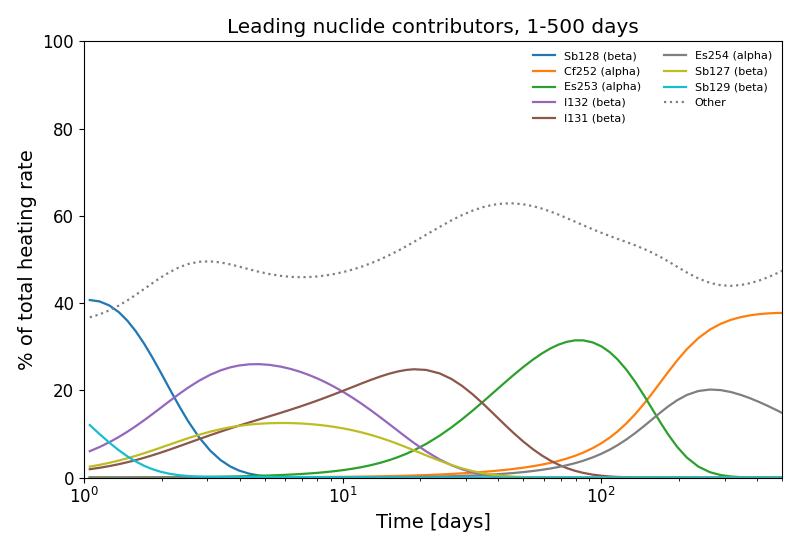

In [11]:
# Rank nuclei by their peak % contribution anywhere inside the [T_MIN_DAYS, T_MAX_DAYS] window
window_mask = (time_days >= T_MIN_DAYS) & (time_days <= T_MAX_DAYS)
eps_window   = contrib_eps[:, window_mask]
total_window = eps_total[window_mask]
pct_window = np.divide(
    eps_window, total_window,
    out=np.zeros_like(eps_window), where=total_window > 0,
) * 100

top_order = np.argsort(-pct_window.max(axis=1))[:TOP_N]

fig_lead, ax_lead = plt.subplots(figsize=(8, 5.5))
colors = plt.get_cmap('tab10')(np.linspace(0, 1, TOP_N))
for color_i, i in zip(colors, top_order):
    ax_lead.plot(time_days[window_mask], pct_window[i], label=contrib_label[i],
                 color=color_i, linewidth=1.6)

other_pct = 100 - pct_window[top_order].sum(axis=0)
ax_lead.plot(time_days[window_mask], np.clip(other_pct, 0, 100), label='Other',
             color='grey', linestyle=':', linewidth=1.6)

ax_lead.set_xscale('log')
ax_lead.set_xlim(T_MIN_DAYS, T_MAX_DAYS)
ax_lead.set_ylim(0, 100)
ax_lead.set_xlabel('Time [days]')
ax_lead.set_ylabel('% of total heating rate')
ax_lead.set_title(f'Leading nuclide contributors, {T_MIN_DAYS}-{T_MAX_DAYS} days')
ax_lead.legend(loc='upper right', ncol=2, fontsize=8, frameon=False)
fig_lead.tight_layout()
fig_lead.savefig('leading_contributors_vs_time.pdf', bbox_inches='tight', dpi=300)

### Interactive explorer: leading contributors at a chosen time

FloatLogSlider(value=1.0, continuous_update=False, description='Time [days]:', layout=Layout(width='80%'), max…

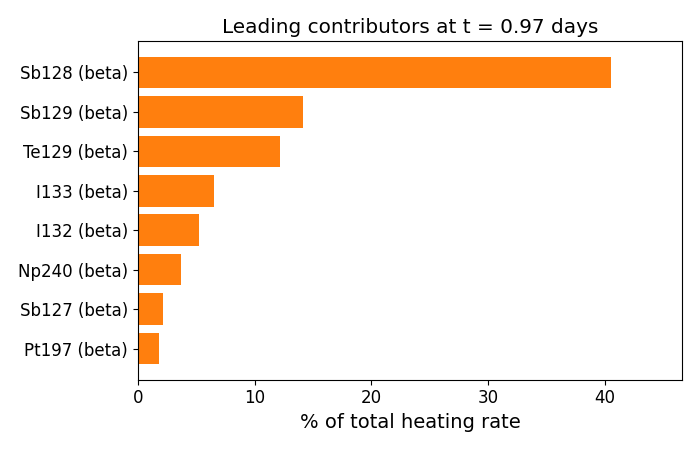

In [12]:
fig_bar, ax_bar = plt.subplots(figsize=(7, 4.5))

def draw_bar(day):
    ax_bar.clear()
    table, t_actual = leading_contributors(day, top_n=TOP_N)
    y = np.arange(len(table))[::-1]
    ax_bar.barh(y, table['% of total'], color='tab:orange')
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(table['nuclide'])
    ax_bar.set_xlabel('% of total heating rate')
    ax_bar.set_xlim(0, max(5, table['% of total'].max() * 1.15))
    ax_bar.set_title(f"Leading contributors at t = {t_actual:.2f} days")
    fig_bar.tight_layout()
    fig_bar.canvas.draw_idle()

draw_bar(T_MIN_DAYS)

day_slider = widgets.FloatLogSlider(
    value=T_MIN_DAYS, base=10,
    min=np.log10(T_MIN_DAYS), max=np.log10(T_MAX_DAYS),
    step=0.01, description='Time [days]:',
    continuous_update=False,
    layout=widgets.Layout(width='80%'),
    style={'description_width': '100px'},
)

def on_change(change):
    draw_bar(change['new'])

day_slider.observe(on_change, names='value')
display(day_slider)